In [4]:
%pip install numpy pandas matplotlib seaborn


   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.7 MB ? eta -:--:--
    --------------------------------------- 0.3/12.7 MB ? eta -:--:--
    --------------------------------------- 0.3/12.7 MB ? eta -:--:--
    --------------------------------------- 0.3/12.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.7 MB 409.2 kB/s eta 0:00:30
   - -------------------------------------- 0.5/12.7 MB 409.2 kB/s eta 0:00:30
   - -------------------------------------- 0.5/12.7 MB 409.2 kB/s eta 0:00:30
   - -------------------------------------- 0.5/12.7 MB 409.2 kB/s eta 0:00:30
   -- ------------------------------------- 0.8/12.7 MB 366.4 kB/s eta 0:00:33
   -- ------------------------------------- 0.8/12.7 MB 366.4 kB/s eta 0:00:33
   -- ------------------------------------- 0.8/12.7 MB 366.4 kB/s eta 0:00:33
   --- --------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [6]:
import sqlite3
import pandas as pd

# 1. Connect to the database
conn = sqlite3.connect('customer_churn.db')

# 2. Fetch table names (fixed unclosed quote)
sql_query = "SELECT name FROM sqlite_master WHERE type = 'table';"
tables = pd.read_sql(sql_query, conn)

# 3. Store DataFrames in a dictionary (recommended best practice)
dfs = {}
for table_name in tables['name']:
    # Fixed missing space after 'FROM'
    dfs[table_name] = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    print(f"Loaded DataFrame for: {table_name}")

# 4. Close connection AFTER the loop finishes
conn.close()

# Access individual DataFrames via dict keys, e.g., dfs['customers']

Loaded DataFrame for: db_customer
Loaded DataFrame for: db_subscription
Loaded DataFrame for: db_support


In [7]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [9]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('customer_churn.db')

# Fetch table names
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

# Print exact names present in your database
print("Tables found:", tables['name'].tolist())

# Store in a dictionary
dfs = {}
for table_name in tables['name']:
    dfs[table_name] = pd.read_sql(f"SELECT * FROM {table_name}", conn)

conn.close()

# Preview the desired table using its exact key name from the printout above
# Example: dfs['customer'].head()

Tables found: ['db_customer', 'db_subscription', 'db_support']


In [11]:
dfs['db_customer'].head()


,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [12]:
#a. rename col_name
#b. drop coloumns_interest and oincode
#c. change data type_dob
#d. data standardization_gender
#e. fix mixing values_country


In [15]:
#a. rename col_name
dfs['db_customer'].rename(columns={'name': 'customer_name'}, inplace=True)

In [17]:
dfs['db_customer'].head()


,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [20]:
dfs['db_customer'] = dfs['db_customer'].drop(columns=['interest', 'pincode'], errors='ignore')

In [21]:
dfs['db_customer'].head()

,customerid,customer_name,country,state,gender,dob,interests
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama


In [22]:
dfs['db_customer'] = dfs['db_customer'].drop(columns=['interest', 'pincode'], errors='ignore')

In [23]:
dfs['db_customer'].head()

,customerid,customer_name,country,state,gender,dob,interests
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama


In [24]:
dfs['db_customer'] = dfs['db_customer'].drop(columns=['interests', 'pincode'], errors='ignore')

In [25]:
dfs['db_customer'].head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00


In [27]:
dfs['db_customer']['dob'] = pd.to_datetime(dfs['db_customer']['dob'], errors='coerce')

In [28]:
dfs['db_customer'].head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [30]:
dfs['db_customer'].info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [32]:
dfs['db_customer']['gender'].unique()

<StringArray>
['Male', 'Female', 'Women', 'Men']
Length: 4, dtype: str

In [35]:
mapping = {
    'Men': 'Male', 'M': 'Male',
    'Women': 'Female', 'F': 'Female'
}

dfs['db_customer']['gender'] = dfs['db_customer']['gender'].replace(mapping)

In [36]:
dfs['db_customer']['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [38]:
dfs['db_customer'][dfs['db_customer']['country'].isna()]


,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [40]:
dfs['db_customer'][dfs['db_customer']['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [41]:
dfs['db_customer']['country'] = dfs['db_customer']['country'].fillna('Nahi Pata')

In [42]:
dfs['db_customer'][dfs['db_customer']['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [46]:
dfs['db_customer']['country'] = dfs['db_customer']['country'].fillna('Nahi Pata')

In [47]:
dfs['db_customer'][dfs['db_customer']['country'] == 'Nahi Pata']

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,Nahi Pata,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,Nahi Pata,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,Nahi Pata,Telangana,Female,2004-12-01


In [48]:
dfs['db_customer']['country'] = dfs['db_customer']['country'].fillna('None')

In [49]:
dfs['db_customer'][dfs['db_customer']['country'] == 'Nahi Pata']

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,Nahi Pata,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,Nahi Pata,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,Nahi Pata,Telangana,Female,2004-12-01


In [50]:
dfs['db_customer'][['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,Nahi Pata,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nahi Pata,Kathmandu
9,Nepal,Kathmandu


In [52]:
# country and state - unique value pair
state_country_mapping = dfs['db_customer'].dropna(subset=['country']).set_index('state')['country'].to_dict()

dfs['db_customer']['country'] = dfs['db_customer']['country'].fillna(dfs['db_customer']['state'].map(state_country_mapping))

In [53]:
dfs['db_customer'][dfs['db_customer']['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [54]:
dfs['db_customer'][['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,Nahi Pata,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nahi Pata,Kathmandu
9,Nepal,Kathmandu


In [55]:
import numpy as np

# 1. Convert 'Nahi Pata' back to NaN
dfs['db_customer']['country'] = dfs['db_customer']['country'].replace('Nahi Pata', np.nan)

# 2. Create state-to-country mapping dictionary
state_mapping = (
    dfs['db_customer']
    .dropna(subset=['country'])
    .set_index('state')['country']
    .to_dict()
)

# 3. Fill NaN country values using the mapped state
dfs['db_customer']['country'] = dfs['db_customer']['country'].fillna(
    dfs['db_customer']['state'].map(state_mapping)
)

In [56]:
dfs['db_customer'][['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [57]:
dfs['db_subscription'].head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [58]:
dfs['db_subscription'].info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [59]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

dfs['db_subscription'][date_col] = dfs['db_subscription'][date_col].apply(pd.to_datetime)
dfs['db_subscription'].info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


In [60]:
dfs['db_support'].head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [61]:
dfs['db_support'].info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [62]:
dfs['db_support'].drop(columns=['col_1', 'comment'], inplace=True)
dfs['db_support']['complaint_date'] = pd.to_datetime(dfs['db_support']['complaint_date'])
dfs['db_support'].info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [63]:
#Feature Engineering and Data Analysis

In [64]:
# create a new col using existing col - churn flag
dfs['db_subscription']['churn_flag'] = np.where(dfs['db_subscription']['cancellation_date'].notna(), 1, 0)

In [65]:
dfs['db_support'].head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [66]:
dfs['db_subscription'].head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [67]:
dfs['db_subscription'].merge(dfs['db_customer'], on='customerid', how='left')

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,22,0,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79,1,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,5,0,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,34,0,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,41,0,arjun,Nepal,Kathmandu,Male,1993-10-29


In [77]:
df = (dfs['db_subscription']
    .merge(dfs['db_customer'], on='customerid', how='left')
    .merge(dfs['db_support'], on='customerid', how='left'))

In [76]:
dfs['db_subscription'].shape

(21, 12)

In [78]:
df.shape

(23, 20)

In [79]:
dfs['db_subscription']['customerid'].nunique()

21

In [80]:
dfs['db_customer']['customerid'].nunique()

21

In [81]:
dfs['db_support']['customerid'].nunique()

7

In [82]:
dfs['db_support']['customerid'].size

9

In [83]:
dfs['db_support']

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [85]:
dfs['db_support']['complaint_count']=dfs['db_support'].groupby('customerid')['customerid'].transform('count')

In [86]:
df.to_csv('exported_churn_data.csv',index=False)

In [88]:
#Data Analysis
#1.Churn Rate


In [91]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score'],
      dtype='str')

In [95]:
churn_rate = df['churn_flag'].mean()*100
print("Churn rate = ", round(churn_rate,2),"%")

Churn rate =  34.78 %


In [96]:
#2. Retention Rate

In [98]:
retention_rate = 100- churn_rate
print("retention_rate = ", round(retention_rate,2),"%")

retention_rate =  65.22 %


In [99]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0


In [100]:
df.groupby('plan_type')['churn_flag'].mean()

plan_type
Basic       0.666667
Premium     0.250000
Standard    0.222222
Name: churn_flag, dtype: float64

In [101]:
# 3. Churn by Plan type 
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           66.67
1   Premium           25.00
2  Standard           22.22


In [105]:
arpu = df['monthly_charges'].mean()
print('ARPU =',round(arpu,2))

ARPU = 18.51


In [106]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score'],
      dtype='str')

In [107]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0


In [111]:
#6. Avg customer tenure
# count of days user has used our service: cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ",round(avg_tenure),0)

Avg Tenure (Days) =  1488 0


In [114]:
# Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at risk (Rs 'k')=", revenue_at_risk)

Revenue at risk (Rs 'k')= 103.91999999999999


In [115]:
# 8. Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  21.74 %


In [120]:
print(df.columns.tolist())

['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score', 'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob', 'complaint_date', 'escalations', 'csat_score', 'tenure_days']


In [121]:
df['complaint_count'] = df['complaint_date'].notna().astype(int)



In [122]:
# Check value counts to verify the new column
print(df['complaint_count'].value_counts())
df.head()

complaint_count
0    14
1     9
Name: count, dtype: int64


,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,tenure_days,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,2012.0,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0,1501.0,1
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,1501.0,1
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,1397.0,0
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,2687.0,0


In [128]:
# 9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg complaint per user =",round(avg_complaints,2))

Avg complaint per user = 0.43


In [126]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'tenure_days',
       'complaint_count'],
      dtype='str')

In [139]:
# 10. Correlation Escalation vs Churn
# Convert 'Y'/'N' to binary numeric values
df['escalation_flag'] = np.where(df['escalations'] == 'Y', 1, 0)

# Create clean DataFrame and calculate correlation
corr_df = df[['escalation_flag', 'churn_flag']].dropna()
correlation = corr_df['escalation_flag'].corr(corr_df['churn_flag'])

print("Correlation Escalation vs Churn =", round(correlation, 2))

Correlation Escalation vs Churn = 0.72


In [140]:
df['churn_score'].head()

0    12
1    91
2    91
3    34
4     8
Name: churn_score, dtype: int64

In [143]:
#Churn risk - create a cloumn using existing col
conditions = [
    (df['churn_score']< 50),
    (df['churn_score']>= 50) & (df['churn_score']< 70),
    (df['churn_score'] >= 70)
]
choices = ['low', 'med','high']
df['churn_risk'] = np.select(conditions,choices,default='unknown')

In [145]:
df[['churn_risk','churn_score']].tail()

,churn_risk,churn_score
18,low,27
19,high,99
20,high,99
21,low,7
22,low,47


In [146]:
#Visualization using matplotlib


In [149]:
df_visual = df.copy()

In [150]:
df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,state,gender,dob,complaint_date,escalations,csat_score,tenure_days,complaint_count,escalation_flag,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,2012.0,0,0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,N,60.0,1501.0,1,0,high
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,1501.0,1,1,high
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,Delhi,Female,1978-02-15,NaT,NaN,NaN,1397.0,0,0,low
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,Nagaland,Male,2001-08-30,NaT,NaN,NaN,2687.0,0,0,low


In [151]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'tenure_days',
       'complaint_count', 'escalation_flag', 'churn_risk'],
      dtype='str')

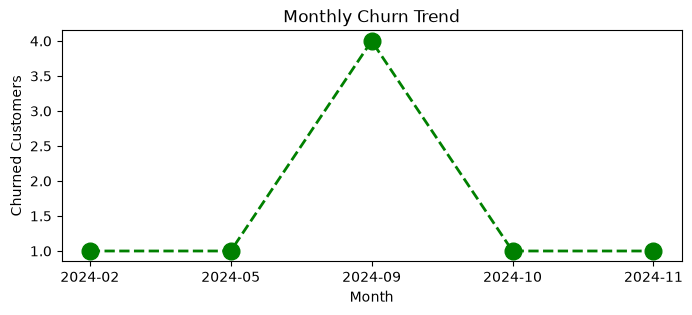

In [163]:
import matplotlib.pyplot as plt

# Monthly Churn Trend(Time Series KPI)
df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8, 3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

cancellation_month
2024-02    1
2024-05    1
2024-09    4
2024-10    1
2024-11    1
Freq: M, dtype: int64

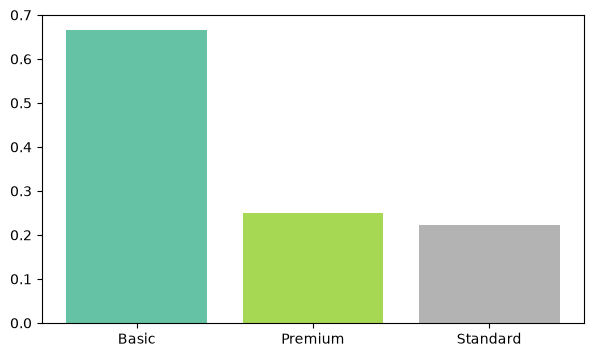

In [168]:
# 4.2 Churn by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()
# colors=['yellow','purple','blue']
colors= plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(7, 4))
plt.bar(churn_plan.index, churn_plan.values,color=colors)
plt.show()

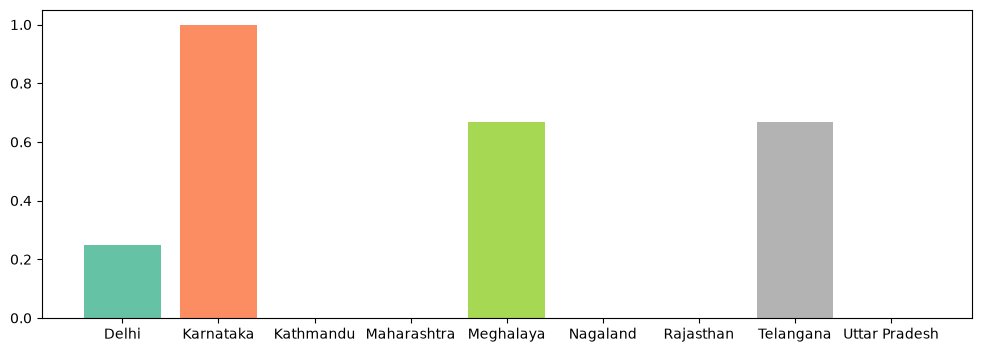

In [170]:
# 4.2 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()
# colors=['yellow','purple','blue']
colors= plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.figure(figsize=(12, 4))
plt.bar(churn_plan.index, churn_plan.values,color=colors)
plt.show()

In [173]:
# Visualization using seaborn

In [174]:
#encoding convert string to numeric values so that we can find corealtion betweeen features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'tenure_days',
       'complaint_count', 'escalation_flag', 'churn_risk',
       'cancellation_month'],
      dtype='str')

In [176]:
# Corrected syntax (added missing quote after 'churn_score')
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()
df_encoded

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,N
2,Premium,Annual,91,1,high,Y
3,Basic,Monthly,34,0,low,NaN
4,Premium,Annual,8,0,low,NaN


In [177]:
# 1. Select full column subset
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].copy()

# 2. Encode categorical string columns to numeric integers
categorical_cols = ['plan_type', 'contract_type', 'churn_risk', 'escalations']
for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# 3. Preview top 5 rows
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,2,0,12,0,1,-1
1,1,0,91,1,0,0
2,1,0,91,1,0,1
3,0,1,34,0,1,-1
4,1,0,8,0,1,-1


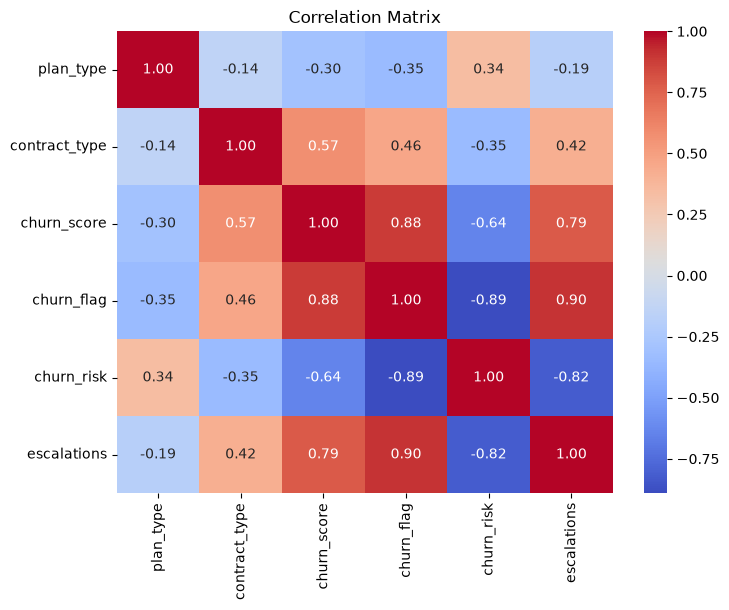

In [182]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap Correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [183]:
df_visual['churn_risk'].unique()

<StringArray>
['low', 'high', 'med']
Length: 3, dtype: str

In [185]:
import pandas as pd

# 1. Select subset with .copy() to avoid SettingWithCopyWarning
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].copy()

# 2. Define custom priority orders
order_mappings = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']  # Ensure case matches your data ('Low' vs 'low')
}

# 3. Apply ordinal encoding
for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col], categories=order, ordered=True).codes

# 4. Map 'escalations' to numeric (1/0) so it works in correlation matrix
df_encoded['escalations'] = (df_encoded['escalations'] == 'Y').astype(int)



In [187]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,N
2,Premium,Annual,91,1,high,Y
3,Basic,Monthly,34,0,low,NaN
4,Premium,Annual,8,0,low,NaN


In [186]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,0
2,2,1,91,1,2,1
3,0,0,34,0,0,0
4,2,1,8,0,0,0


<Axes: >

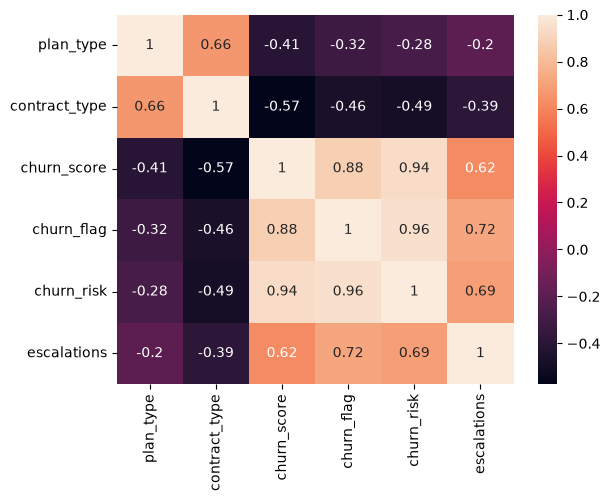

In [188]:
#Heatmap Corelation matrix
sns.heatmap(df_encoded.corr(), annot=True)

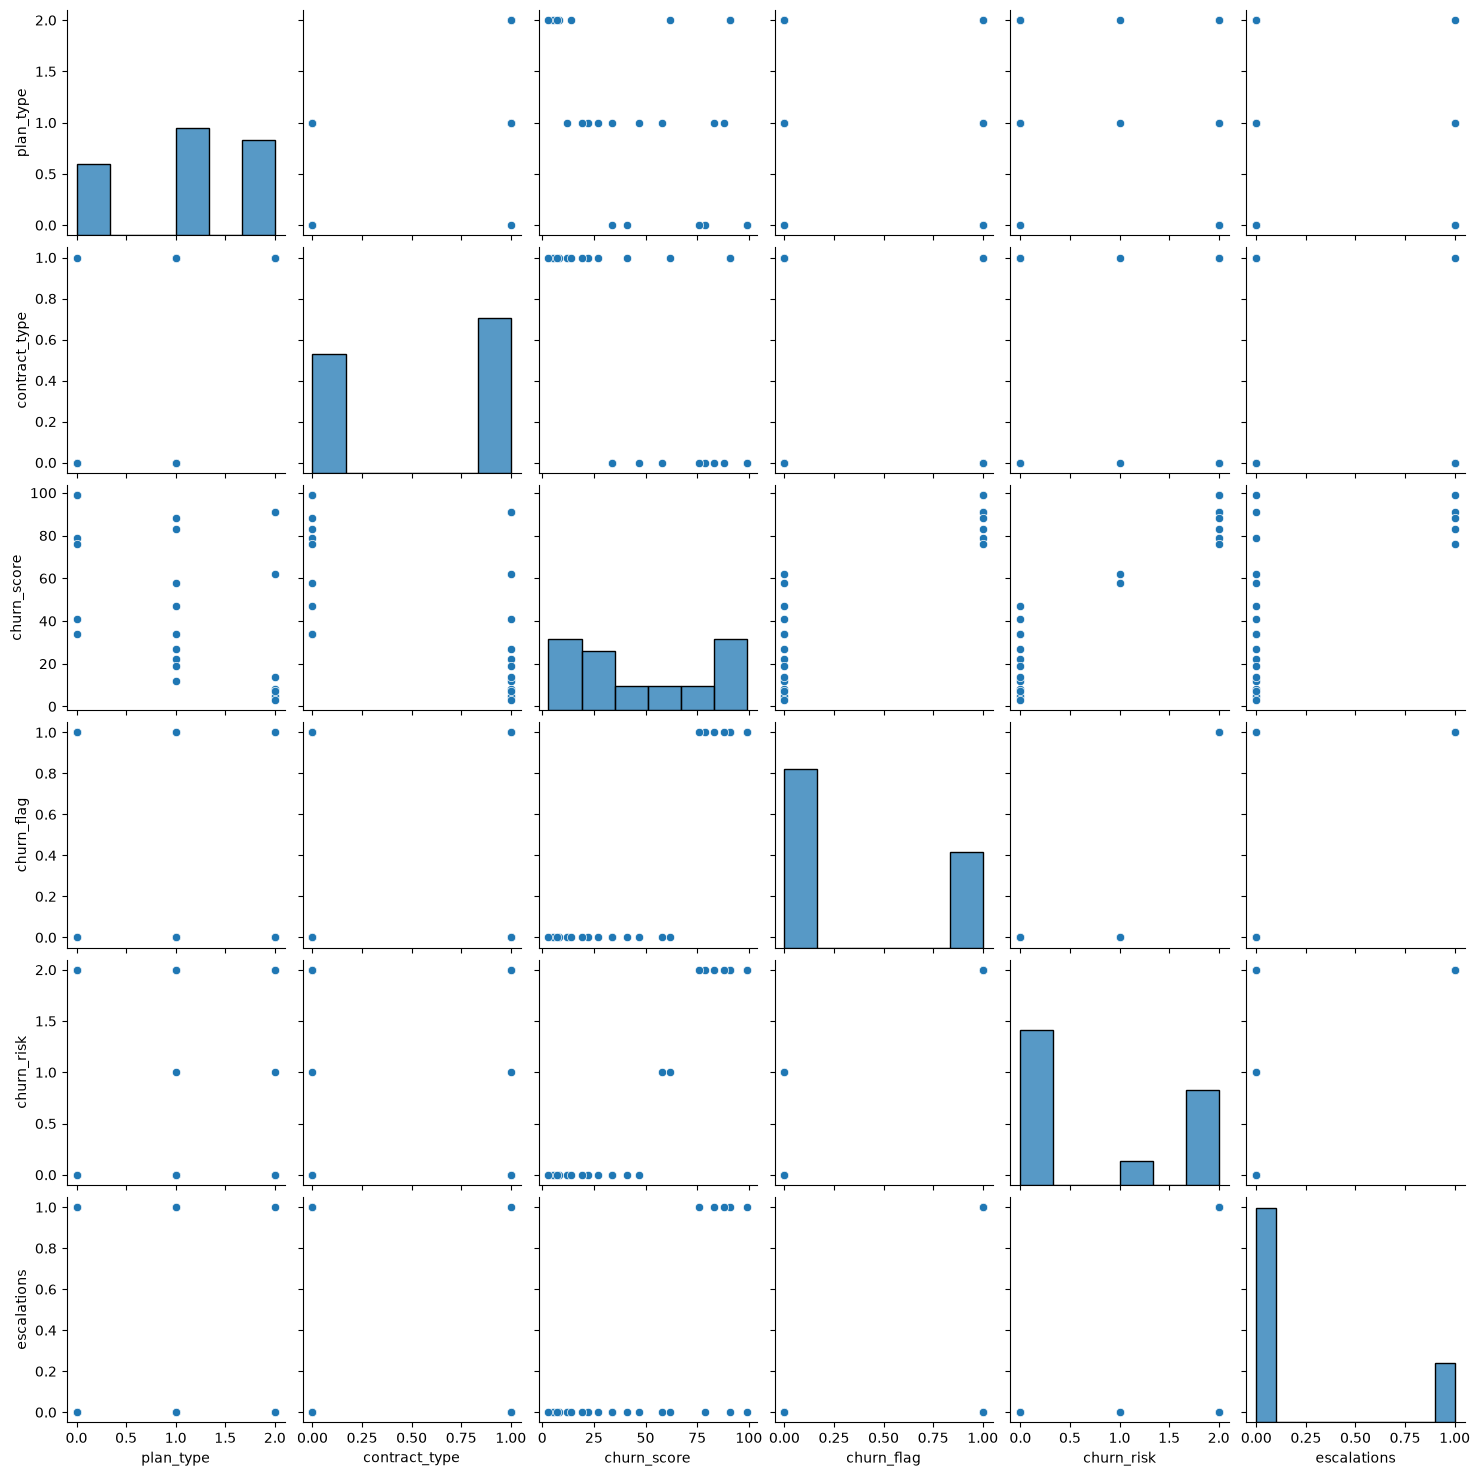

In [190]:
# pairplot
sns.pairplot(df_encoded)
plt.show()

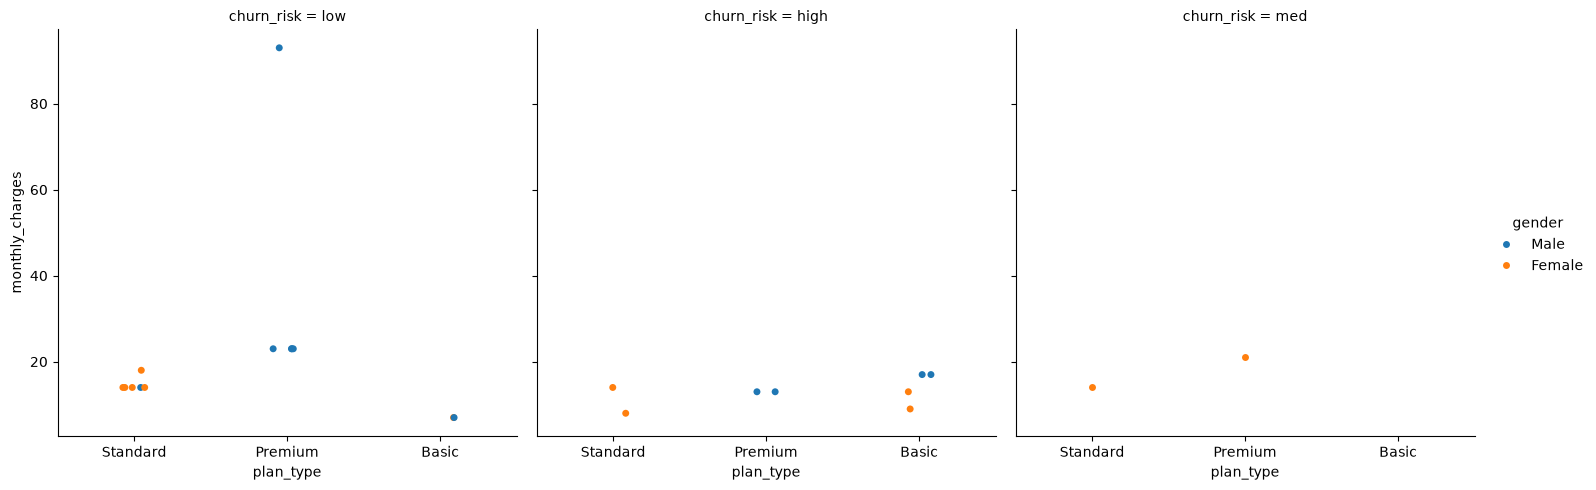

In [191]:
#catplot/FacegridPlot -multi-dim comparison

sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn_risk')

In [195]:
pivot_res = pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc={
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag': 'mean'
    }
)

pivot_res

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.666667,5,69.94
Premium,0.250000,7,231.92
Standard,0.222222,9,123.91


In [ ]:
# working with sql in python(pandas)

In [196]:
#create db in sql
conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT,country TEXT,budget INTEGER )")

#commit and save
conn.commit()

In [199]:
# insert data
cursor = conn.cursor()

# write sql query to insert records in sql table
cursor.execute(
    """
    INSERT INTO users VALUES 
        ('Madhav', 'India', 5000),
        ('Rishav', 'Germany', 2500),
        ('Vishaka', 'India', 3500)
    """
)
# commit and save
conn.commit()

print("Data Inserted Successfully")

Data Inserted Successfully


In [202]:
import sqlite3
import pandas as pd

# Connect to database file
conn = sqlite3.connect('test_database_sqlite.db')
cursor = conn.cursor()

# 1. Create table schema if it doesn't exist
cursor.execute('''
    CREATE TABLE IF NOT EXISTS users (
        name TEXT,
        country TEXT,
        balance REAL
    )
''')

# 2. Insert records cleanly
cursor.execute('''
    INSERT INTO users (name, country, balance) VALUES 
        ('Madhav', 'India', 5000),
        ('Rishav', 'Germany', 2500),
        ('Vishaka', 'India', 3500)
''')
conn.commit()

# 3. Read back into Pandas DataFrame
query = "SELECT * FROM users"
df_results = pd.read_sql(query, conn)
conn.close()

df_results.head()

,name,country,balance
0,Madhav,India,5000.0
1,Rishav,Germany,2500.0
2,Vishaka,India,3500.0


In [204]:
import sqlite3
import pandas as pd

# Re-open connection
conn = sqlite3.connect('test_database_sqlite.db')

# Update column name to 'balance' if that was used in your CREATE/INSERT statement
query = """
    SELECT country, SUM(balance) AS total_budget
    FROM users
    GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
conn.close()

df_agg

,country,total_budget
0,Germany,2500.0
1,India,8500.0


In [205]:
conn.close()